In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from ingredient_parser import parse_ingredient
from collections import Counter
from wordcloud import WordCloud
from matplotlib_venn import venn2


In [ ]:
# Cargamos el dataset original
df = pd.read_csv("/Users/franky/Desktop/Recipe recommender/datasets/recetas.csv")

In [91]:
df.head()

,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src,date
0,Fruit and Yogurt Smoothie,5 mins,NaN,5 mins,2,NaN,"1 cup strawberries, 1 banana, ½ cup yogurt, ¼...","Combine strawberries, banana, yogurt, pineappl...",4.7,https://www.allrecipes.com/recipe/215189/fruit...,/Drinks Recipes/Smoothie Recipes/Strawberry/,"Total Fat 1g 2%, Saturated Fat 1g 4%, Choleste...","Prep Time: 5 mins, Total Time: 5 mins, Serving...",https://www.allrecipes.com/thmb/nXTnAdimMBtkQi...,2026-05-01
1,"Orange, Fig, and Gorgonzola Salad",15 mins,NaN,15 mins,4,4 servings,"2 heads romaine lettuce, chopped, 2 oranges -...","Combine lettuce, oranges, Gorgonzola cheese, a...",4.7,https://www.allrecipes.com/recipe/234219/orang...,/Salad/Fruit Salad Recipes/Orange Salad Recipes/,"Total Fat 7g 8%, Saturated Fat 4g 19%, Cholest...","Prep Time: 15 mins, Total Time: 15 mins, Servi...",https://www.allrecipes.com/thmb/_qqHaDK6ZWLhH1...,2026-05-01
2,Fresh Fruit Basket Cobbler,20 mins,20 mins,1 hrs,8,1 8x13-inch dish,"2 cups sliced fresh peaches, 2 cups sliced fre...",Preheat oven to 350 degrees F (175 degrees C)....,4.5,https://www.allrecipes.com/recipe/215149/fresh...,/Desserts/Fruit Desserts/Peach Dessert Recipes/,"Total Fat 8g 10%, Saturated Fat 2g 10%, Choles...","Prep Time: 20 mins, Cook Time: 20 mins, Additi...",https://www.allrecipes.com/thmb/M2HlzlgXhGsLA1...,2026-05-01
3,Caramel Apples,8 mins,2 mins,25 mins,6,6 caramel apples,"6 apples, 6 wooden craft sticks, cooking s...",Remove the stem from each apple and press a cr...,4.4,https://www.allrecipes.com/recipe/21130/carame...,/Desserts/Specialty Dessert Recipes/Caramel Ap...,"Total Fat 6g 7%, Saturated Fat 2g 9%, Choleste...","Prep Time: 8 mins, Cook Time: 2 mins, Addition...",https://www.allrecipes.com/thmb/Gc2LqawZpqaCSW...,2026-05-01
4,Sweet Coconut Rice,5 mins,20 mins,25 mins,4,4 servings,"1 ½ cups long-grain white rice, 1 (14 ounce) c...","Stir rice, coconut milk, and water together in...",4.5,https://www.allrecipes.com/recipe/237021/sweet...,/Side Dish/Rice Side Dish Recipes/,"Total Fat 22g 28%, Saturated Fat 19g 95%, Sodi...","Prep Time: 5 mins, Cook Time: 20 mins, Total T...",https://www.allrecipes.com/thmb/3LmVEctbWeHFsr...,2026-05-01


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe_name   1090 non-null   str    
 1   prep_time     1039 non-null   str    
 2   cook_time     782 non-null    str    
 3   total_time    1045 non-null   str    
 4   servings      1090 non-null   int64  
 5   yield         879 non-null    str    
 6   ingredients   1090 non-null   str    
 7   directions    1090 non-null   str    
 8   rating        1090 non-null   float64
 9   url           1090 non-null   str    
 10  cuisine_path  1090 non-null   str    
 11  nutrition     1090 non-null   str    
 12  timing        1090 non-null   str    
 13  img_src       1090 non-null   str    
 14  date          1090 non-null   str    
dtypes: float64(1), int64(1), str(13)
memory usage: 127.9 KB


In [93]:
df.nunique()

recipe_name     961
prep_time        21
cook_time        58
total_time      120
servings         43
yield           312
ingredients     961
directions      961
rating           20
url             961
cuisine_path    353
nutrition       961
timing          848
img_src         961
date             61
dtype: int64

### Lo que vamos a necesitar es hacer una lista de ingredientes solos, sin medidas ni porciones.

In [94]:
# Hago lista de ingredientes para cada receta, separando por comas y quitando espacios
df['ingredients_list'] = df['ingredients'].apply(
    lambda x: [i.strip() for i in x.split(',')]
)

In [ ]:
# Parsear cada ingrediente 
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/franky/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to /Users/franky/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
# Extrae los nombres de lo ingredientes
def extract_ingredient_names(ingredients_list):

    parsed = [parse_ingredient(x) for x in ingredients_list]

    names = []

    for p in parsed:
        if p.name:
            names.append(p.name[0].text)

    return names

In [97]:
# Aplco la función a cada receta
df['clean_ingredients'] = df['ingredients_list'].apply(
    extract_ingredient_names
)

In [98]:
df['clean_ingredients'][0]

['strawberries',
 'banana',
 'yogurt',
 'pineapple juice',
 'white sugar',
 'orange juice',
 'milk']

In [99]:
df['ingredients_list'][0]

['1 cup strawberries',
 '1  banana',
 '½ cup yogurt',
 '¼ cup pineapple juice',
 '1 ½ teaspoons white sugar',
 '1 teaspoon orange juice',
 '1 teaspoon milk']

### El siguiente paso es analizar ingredientes, ratings, etc

In [ ]:
# Analizamos la frecuencia de los ingredientes para ver cuáles son los más comunes
counter = Counter()

for recipe in df['clean_ingredients']:
    counter.update(recipe)

counter.most_common(20)

[('white sugar', 593),
 ('salt', 423),
 ('butter', 333),
 ('all-purpose flour', 328),
 ('ground cinnamon', 275),
 ('vanilla extract', 206),
 ('brown sugar', 187),
 ('eggs', 186),
 ('water', 182),
 ('baking powder', 145),
 ('milk', 135),
 ('baking soda', 134),
 ('lemon juice', 112),
 ('egg', 94),
 ('ground nutmeg', 92),
 ('vegetable oil', 91),
 ('apples', 86),
 ('garlic', 83),
 ('walnuts', 82),
 ('olive oil', 78)]

Top 20 ingredientes:
[('white sugar', 593), ('salt', 423), ('butter', 333), ('all-purpose flour', 328), ('ground cinnamon', 275), ('vanilla extract', 206), ('brown sugar', 187), ('eggs', 186), ('water', 182), ('baking powder', 145), ('milk', 135), ('baking soda', 134), ('lemon juice', 112), ('egg', 94), ('ground nutmeg', 92), ('vegetable oil', 91), ('apples', 86), ('garlic', 83), ('walnuts', 82), ('olive oil', 78)]


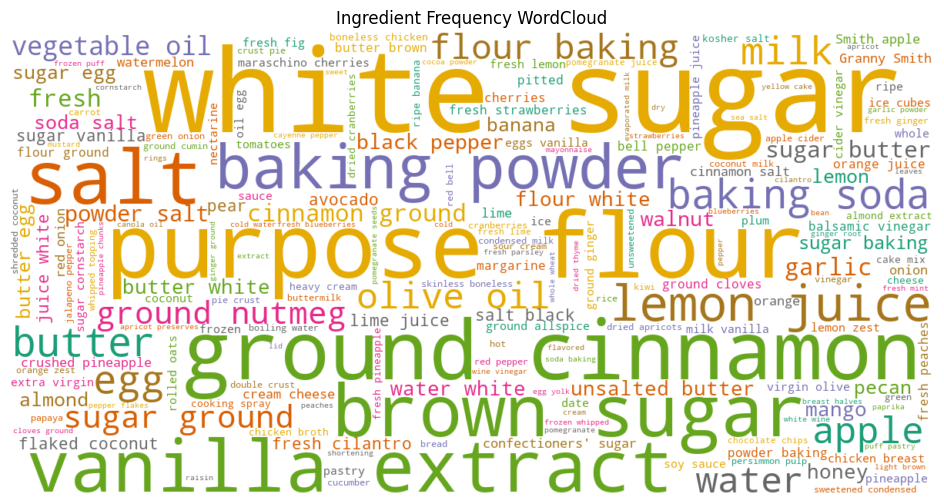

In [ ]:

# =========================
# 1. Asegurar formato correcto
# =========================
# df['clean_ingredients'] debe ser lista de listas tipo:
# [['banana', 'milk'], ['yogurt', 'strawberries'], ...]

# =========================
# 2. Counter (frecuencias)
# =========================
counter = Counter()

for recipe in df['clean_ingredients']:
    counter.update(recipe)

print("Top 20 ingredientes:")
print(counter.most_common(20))

# =========================
# 3. WordCloud global
# =========================
all_ingredients = " ".join(
    [" ".join(recipe) for recipe in df['clean_ingredients']]
)

wc = WordCloud(
    background_color="white",
    colormap="Dark2",
    max_font_size=150,
    width=1200,
    height=600,
    random_state=42
)

wc.generate(all_ingredients)

# =========================
# 4. Plot
# =========================
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Ingredient Frequency WordCloud")
plt.show()

#### Analizo la parte numerica

In [ ]:
# Transformar la columna de fecha a formato datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')


In [103]:
df.describe()

,servings,rating,date
count,1090.000000,1090.000000,1090
mean,13.755046,4.533853,2026-05-31 00:34:20.917431
min,1.000000,2.000000,2026-05-01 00:00:00
25%,6.000000,4.400000,2026-05-16 00:00:00
50%,8.000000,4.600000,2026-05-30 00:00:00
75%,12.000000,4.700000,2026-06-15 00:00:00
max,240.000000,5.000000,2026-06-30 00:00:00
std,19.886076,0.349814,NaN


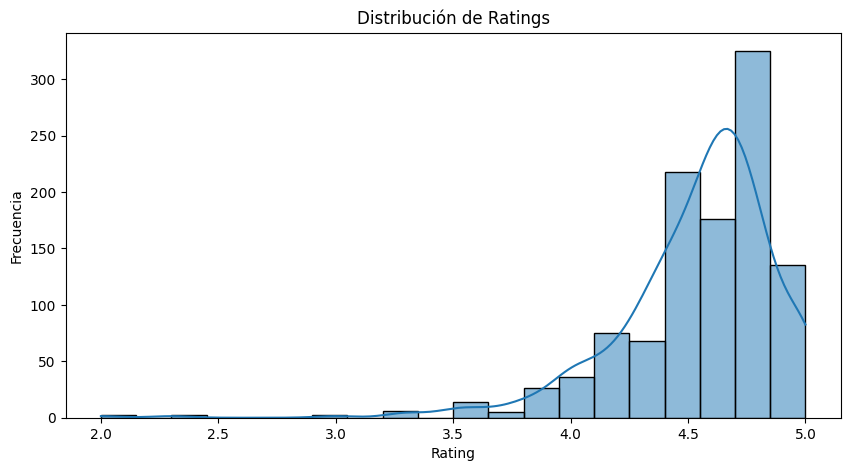

In [ ]:
# Grafico de distribución de ratings
plt.figure(figsize=(10,5))

sns.histplot(
    df['rating'].dropna(),
    bins=20,
    kde=True
)

plt.title("Distribución de Ratings")
plt.xlabel("Rating")
plt.ylabel("Frecuencia")

plt.show()

In [105]:
df['rating'].value_counts(normalize=True).sort_index()

rating
2.0    0.001835
2.3    0.001835
3.0    0.001835
3.3    0.005505
3.5    0.007339
3.6    0.005505
3.7    0.004587
3.8    0.011009
3.9    0.012844
4.0    0.033028
4.1    0.029358
4.2    0.039450
4.3    0.062385
4.4    0.093578
4.5    0.106422
4.6    0.161468
4.7    0.176147
4.8    0.122018
4.9    0.047706
5.0    0.076147
Name: proportion, dtype: float64

In [ ]:
# Top 50 ingredientes más comunes
counter = Counter()

for recipe in df['clean_ingredients']:
    counter.update(recipe)

top_50 = counter.most_common(50)

top_50_df = pd.DataFrame(top_50, columns=["ingredient", "count"])

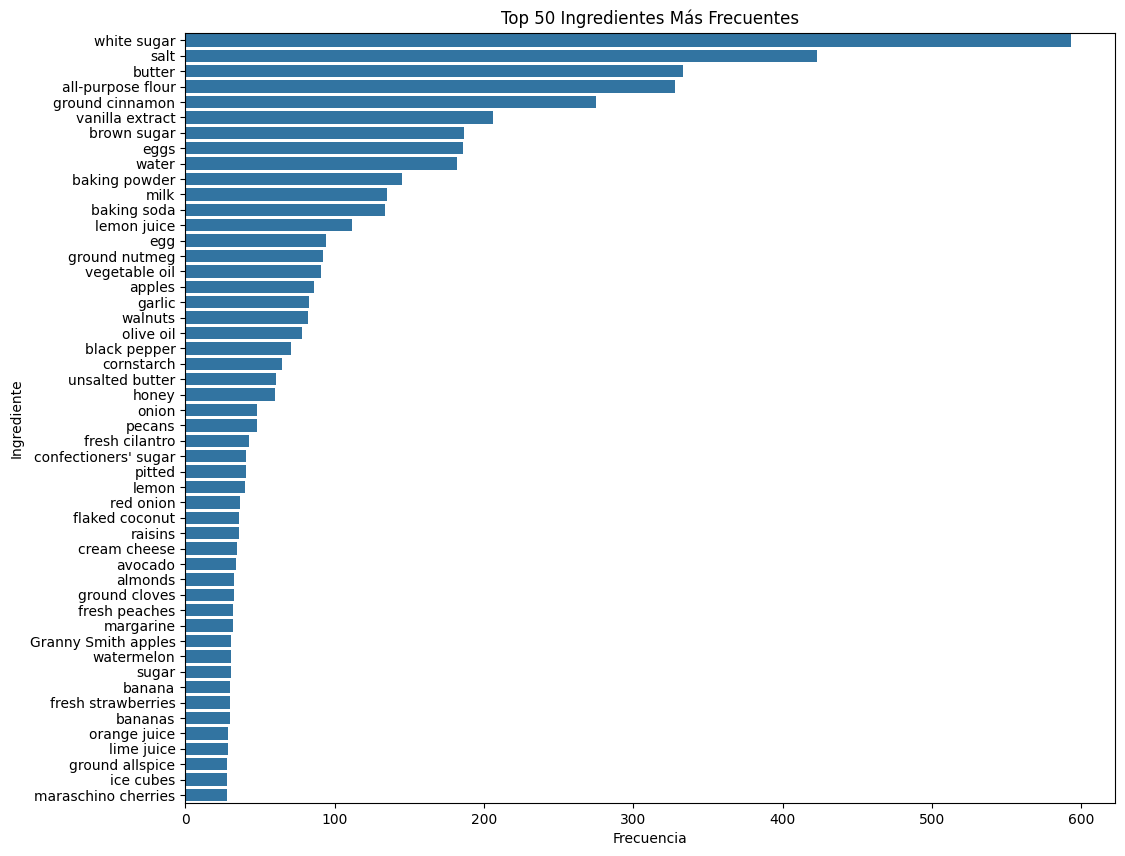

In [ ]:
# Plot de los 50 ingredientes más comunes
plt.figure(figsize=(12,10))

sns.barplot(
    data=top_50_df,
    y="ingredient",
    x="count"
)

plt.title("Top 50 Ingredientes Más Frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Ingrediente")

plt.show()

In [108]:
# Filtramos las filas donde 'sugar' está presente en la lista de ingredientes
# Usamos una función lambda para revisar elemento por elemento
recetas_con_azucar = df[df['clean_ingredients'].apply(lambda lista: any('sugar' in ing.lower() for ing in lista))]

cantidad = len(recetas_con_azucar)
total_recetas = len(df)
porcentaje = (cantidad / total_recetas) * 100

print(f"Resultados de la prueba:")
print(f"- Cantidad de recetas con azúcar: {cantidad}")
print(f"- Porcentaje del total: {porcentaje:.2f}%")

Resultados de la prueba:
- Cantidad de recetas con azúcar: 730
- Porcentaje del total: 66.97%


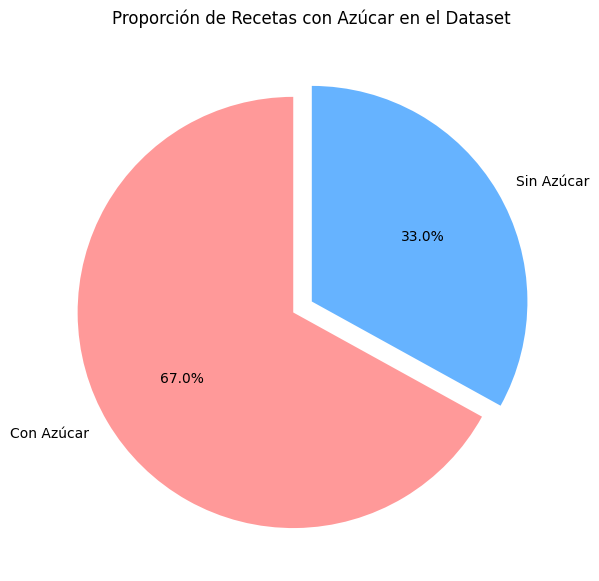

In [109]:
# Gráfico de proporcion de recetas
sizes = [cantidad, total_recetas - cantidad]
colors = ['#ff9999','#66b3ff']

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=(0.1, 0))
plt.title('Proporción de Recetas con Azúcar en el Dataset')
plt.show()

### Analizamos la proporción de recetas con azúcar y sin 

In [110]:
# Creamos la columna 'w_sugar'
# 1 si contiene azúcar (o derivados), 0 si no
df['w_sugar'] = df['clean_ingredients'].apply(
    lambda lista: 1 if any('sugar' in ing.lower() for ing in lista) else 0
)

# Verificamos rápidamente la distribución
print(df['w_sugar'].value_counts(normalize=True))

w_sugar
1    0.669725
0    0.330275
Name: proportion, dtype: float64


In [111]:
"""
Este análisis utiliza la teoría de conjuntos para identificar qué ingredientes pertenecen exclusivamente al mundo dulce (w_sugar == 1)
y cuáles al mundo salado (w_sugar == 0). El objetivo es encontrar oportunidades de innovación (ingredientes que funcionan en un contexto
y podrían ser tendencia en el otro)
"""

# 1. Creamos los conjuntos de ingredientes por grupo
dulces_ings = set([ing for lista in df[df['w_sugar'] == 1]['clean_ingredients'] for ing in lista])
saladas_ings = set([ing for lista in df[df['w_sugar'] == 0]['clean_ingredients'] for ing in lista])

# 2. Identificamos los ingredientes exclusivos de cada mundo
solo_en_dulces = dulces_ings - saladas_ings
solo_en_saladas = saladas_ings - dulces_ings

print(f"Total ingredientes exclusivos en dulces: {len(solo_en_dulces)}")
print(f"Total ingredientes exclusivos en saladas: {len(solo_en_saladas)}")

# 3. Candidatos para innovar (Crossover)
# Estos son ingredientes que hoy solo usas en dulces, pero podrías 'importar' a lo salado
print("\nIngredientes de dulces para probar en platos salados:")
print(list(solo_en_dulces)[:15]) 

print("\nIngredientes salados para probar en repostería creativa:")
print(list(solo_en_saladas)[:15])

Total ingredientes exclusivos en dulces: 528
Total ingredientes exclusivos en saladas: 514

Ingredientes de dulces para probar en platos salados:
['pitted sweet cherries', 'raisin paste', 'old-fashioned oats', 'soy milk', 'ground cherries', 'powdered gelatin', 'custard powder', 'apple juice', 'flaky biscuits', 'Macintosh apples', 'whole blueberries', 'coconut flavoring', 'mochiko', 'fat-free evaporated milk', 'ground coriander seed']

Ingredientes salados para probar en repostería creativa:
['with greens', 'orzo pasta', 'serrano chile peppers', 'low-sodium chicken broth', 'Hungarian paprika', 'Benedictine liqueur', 'vanilla soy milk', 'patted dry', 'cottage cheese', 'tangy coconut and chili vindaloo sauce', 'instant vanilla pudding', 'harissa', 'red raspberry jam (with seeds)', 'oyster sauce', 'tonic water']


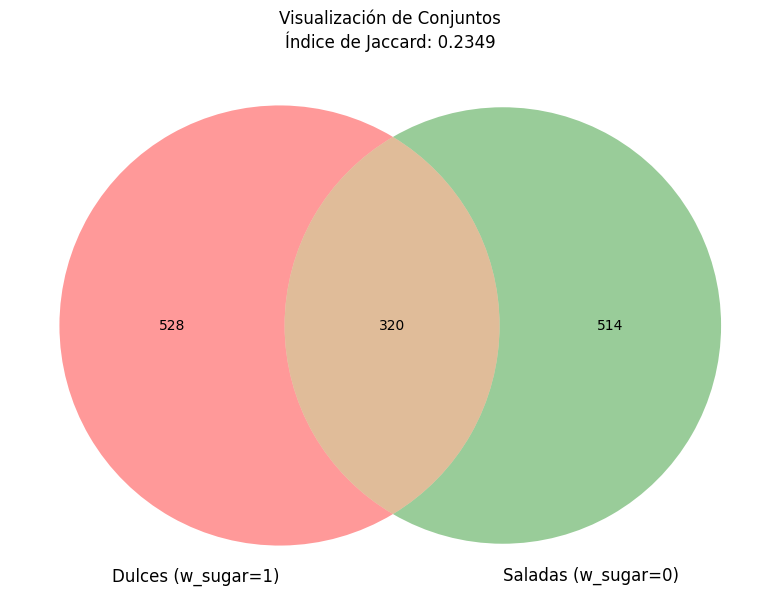

Muestra de recetas saladas que están innovando (usando ingredientes comunes con dulces):


In [ ]:
# --- PASO 1: Crear los conjuntos de ingredientes ---
# Extraemos ingredientes únicos para Dulces (1) y Salados (0)
d_ings = set([ing for lista in df[df['w_sugar'] == 1]['clean_ingredients'] for ing in lista])
s_ings = set([ing for lista in df[df['w_sugar'] == 0]['clean_ingredients'] for ing in lista])

# --- PASO 2: Identificar la Intersección (El puente) ---
interseccion = d_ings.intersection(s_ings)

# --- PASO 3: Visualización con Diagrama de Venn ---
plt.figure(figsize=(10, 7))
v = venn2([d_ings, s_ings], set_labels=('Dulces (w_sugar=1)', 'Saladas (w_sugar=0)'))

# Estilo del gráfico
plt.title(f"Visualización de Conjuntos\nÍndice de Jaccard: {len(interseccion)/len(d_ings.union(s_ings)):.4f}")
plt.show()

# --- PASO 4: Ver las recetas que están en la 'zona de experimentación' ---
# Buscamos recetas SALADAS que usen ingredientes típicos de DULCES
# (Excluimos sal y agua para que los resultados sean más interesantes)
ruido = {'salt', 'water', 'oil', 'sugar'} 
interseccion_interesante = interseccion - ruido

# Filtramos recetas saladas que usan ingredientes de la intersección
recetas_crossover = df[
    (df['w_sugar'] == 0) & 
    (df['clean_ingredients'].apply(lambda x: any(i in interseccion_interesante for i in x)))
]

print("Muestra de recetas saladas que están innovando (usando ingredientes comunes con dulces):")


### Lo siguiente es analizar en el tiempo

In [113]:
df.head()

,recipe_name,prep_time,cook_time,total_time,servings,yield,ingredients,directions,rating,url,cuisine_path,nutrition,timing,img_src,date,ingredients_list,clean_ingredients,w_sugar
0,Fruit and Yogurt Smoothie,5 mins,NaN,5 mins,2,NaN,"1 cup strawberries, 1 banana, ½ cup yogurt, ¼...","Combine strawberries, banana, yogurt, pineappl...",4.7,https://www.allrecipes.com/recipe/215189/fruit...,/Drinks Recipes/Smoothie Recipes/Strawberry/,"Total Fat 1g 2%, Saturated Fat 1g 4%, Choleste...","Prep Time: 5 mins, Total Time: 5 mins, Serving...",https://www.allrecipes.com/thmb/nXTnAdimMBtkQi...,2026-05-01,"[1 cup strawberries, 1 banana, ½ cup yogurt, ...","[strawberries, banana, yogurt, pineapple juice...",1
1,"Orange, Fig, and Gorgonzola Salad",15 mins,NaN,15 mins,4,4 servings,"2 heads romaine lettuce, chopped, 2 oranges -...","Combine lettuce, oranges, Gorgonzola cheese, a...",4.7,https://www.allrecipes.com/recipe/234219/orang...,/Salad/Fruit Salad Recipes/Orange Salad Recipes/,"Total Fat 7g 8%, Saturated Fat 4g 19%, Cholest...","Prep Time: 15 mins, Total Time: 15 mins, Servi...",https://www.allrecipes.com/thmb/_qqHaDK6ZWLhH1...,2026-05-01,"[2 heads romaine lettuce, chopped, 2 oranges ...","[romaine lettuce, oranges, pith, Gorgonzola ch...",0
2,Fresh Fruit Basket Cobbler,20 mins,20 mins,1 hrs,8,1 8x13-inch dish,"2 cups sliced fresh peaches, 2 cups sliced fre...",Preheat oven to 350 degrees F (175 degrees C)....,4.5,https://www.allrecipes.com/recipe/215149/fresh...,/Desserts/Fruit Desserts/Peach Dessert Recipes/,"Total Fat 8g 10%, Saturated Fat 2g 10%, Choles...","Prep Time: 20 mins, Cook Time: 20 mins, Additi...",https://www.allrecipes.com/thmb/M2HlzlgXhGsLA1...,2026-05-01,"[2 cups sliced fresh peaches, 2 cups sliced fr...","[fresh peaches, fresh nectarines, plums, corns...",1
3,Caramel Apples,8 mins,2 mins,25 mins,6,6 caramel apples,"6 apples, 6 wooden craft sticks, cooking s...",Remove the stem from each apple and press a cr...,4.4,https://www.allrecipes.com/recipe/21130/carame...,/Desserts/Specialty Dessert Recipes/Caramel Ap...,"Total Fat 6g 7%, Saturated Fat 2g 9%, Choleste...","Prep Time: 8 mins, Cook Time: 2 mins, Addition...",https://www.allrecipes.com/thmb/Gc2LqawZpqaCSW...,2026-05-01,"[6 apples, 6 wooden craft sticks, cooking sp...","[apples, wooden craft sticks, cooking spray, i...",0
4,Sweet Coconut Rice,5 mins,20 mins,25 mins,4,4 servings,"1 ½ cups long-grain white rice, 1 (14 ounce) c...","Stir rice, coconut milk, and water together in...",4.5,https://www.allrecipes.com/recipe/237021/sweet...,/Side Dish/Rice Side Dish Recipes/,"Total Fat 22g 28%, Saturated Fat 19g 95%, Sodi...","Prep Time: 5 mins, Cook Time: 20 mins, Total T...",https://www.allrecipes.com/thmb/3LmVEctbWeHFsr...,2026-05-01,"[1 ½ cups long-grain white rice, 1 (14 ounce) ...","[long-grain white rice, coconut milk, water, w...",1


In [114]:
# 1. Asegurarnos de que 'date' sea datetime
df['date'] = pd.to_datetime(df['date'])

# 2. Contar la cantidad de ingredientes
# Usamos 'clean_ingredients' que ya parece ser una lista
df['num_ingredients'] = df['clean_ingredients'].apply(len)

In [115]:
# Agrupar por fecha y calcular el promedio de ingredientes
variacion_temporal = df.groupby('date')['num_ingredients'].mean().reset_index()

print(variacion_temporal)

         date  num_ingredients
0  2026-05-01         7.000000
1  2026-05-02         9.214286
2  2026-05-03         8.277778
3  2026-05-04         8.833333
4  2026-05-05         8.571429
..        ...              ...
56 2026-06-26         7.222222
57 2026-06-27         9.687500
58 2026-06-28         8.428571
59 2026-06-29         7.875000
60 2026-06-30         9.538462

[61 rows x 2 columns]


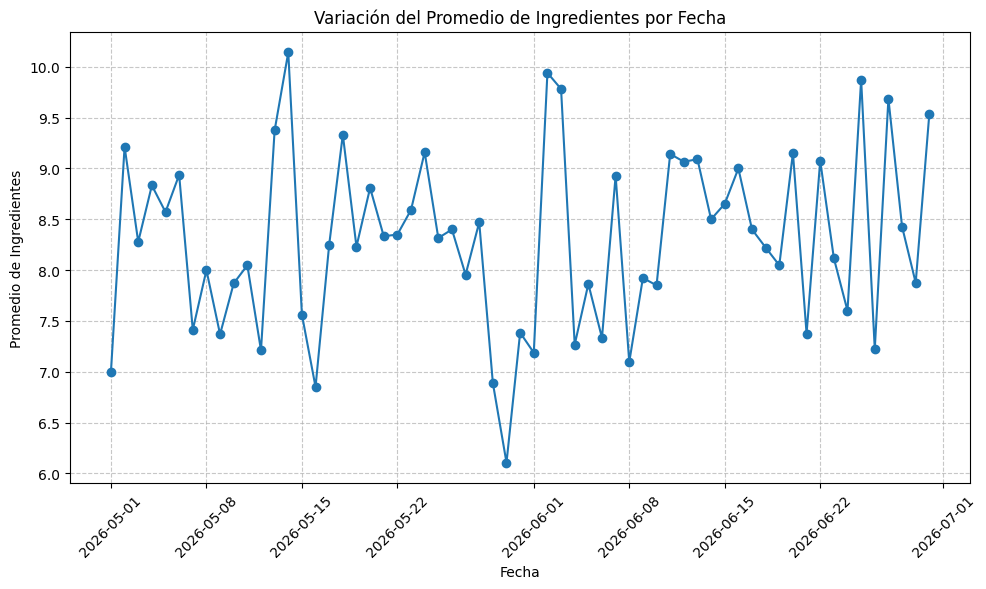

In [ ]:
# Plot de la variación temporal del promedio de ingredientes
plt.figure(figsize=(10, 6))
plt.plot(variacion_temporal['date'], variacion_temporal['num_ingredients'], marker='o', linestyle='-')

plt.title('Variación del Promedio de Ingredientes por Fecha')
plt.xlabel('Fecha')
plt.ylabel('Promedio de Ingredientes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

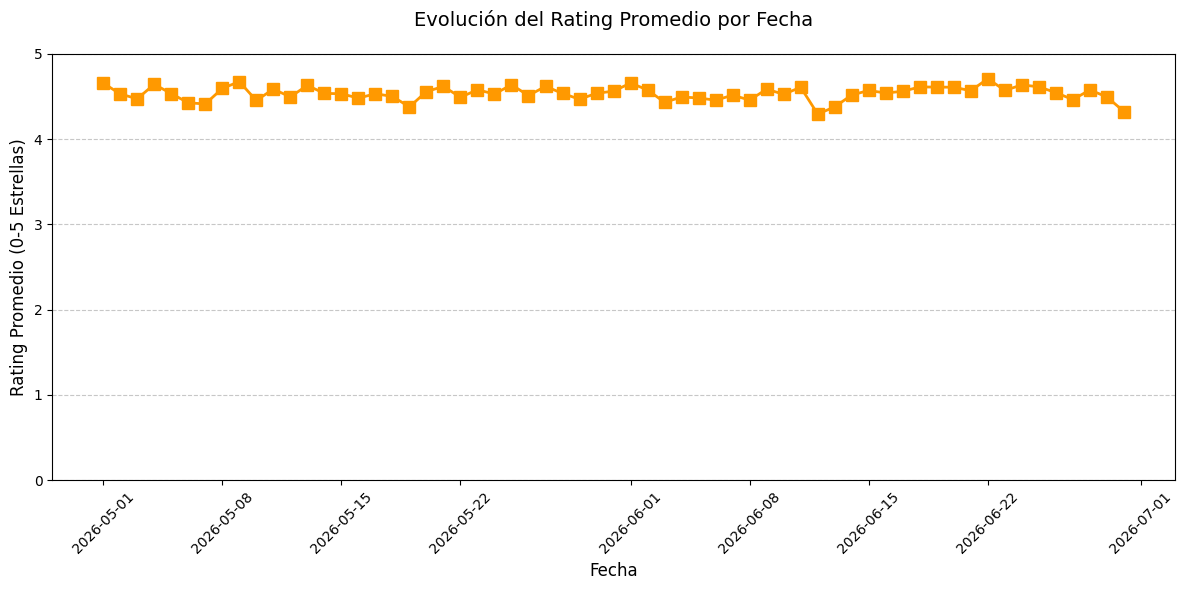

In [ ]:
# Plot de la variación temporal del promedio de rating

# 1. Asegurar formato de fecha
df['date'] = pd.to_datetime(df['date'])

# 2. Agrupar por fecha y obtener el rating promedio
rating_temporal = df.groupby('date')['rating'].mean().reset_index()

# 3. Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(rating_temporal['date'], rating_temporal['rating'], 
         marker='s',           # Marcadores cuadrados
         color='#FF9900',      # Color naranja "estilo rating"
         linestyle='-', 
         linewidth=2,
         markersize=8)

# Configuración de estética y escalas
plt.title('Evolución del Rating Promedio por Fecha', fontsize=14, pad=20)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rating Promedio (0-5 Estrellas)', fontsize=12)

# Ajuste importante: Fijar el eje Y de 0 a 5 para no exagerar variaciones pequeñas
plt.ylim(0, 5) 

plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
## ==== Exporto el csv con los ingredientes limpios
#df.to_csv("/Users/franky/Desktop/Recipe recommender/datasets/recetas_full.csv", index=False)